# Adult Income — Pipeline Treningowy

Predykcja czy osoba zarabia >50K USD rocznie na podstawie cech demograficznych.

**Dataset:** UCI Adult Census Income (~32k rzędów, klasyfikacja binarna)  
**Target:** `income` → 1 jeśli `>50K`, 0 jeśli `<=50K`  
**Stack:** pandas, scikit-learn, lightgbm, joblib

**Pipeline:**
1. Wczytanie danych (lokalnie → później z MinIO/S3)
2. EDA + czyszczenie
3. Feature selection (mutual information)
4. Trening (Logistic Regression baseline + LightGBM)
5. Walidacja (stratified k-fold, AUC/F1)
6. Zapis modelu lokalnie + (opcjonalnie) do MinIO/S3


## 0. Setup

In [2]:
# Instalacja zależności (odkomentuj jeśli potrzebne)
!pip install pandas scikit-learn lightgbm joblib matplotlib seaborn boto3 --quiet

In [1]:
import os
import json
import joblib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import lightgbm as lgb

warnings.filterwarnings("ignore")
# sns.set_style("whitegrid")

# Konfiguracja
RANDOM_STATE = 42
DATA_PATH = "adult.csv"          # zmień jeśli plik jest gdzie indziej
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)
print("Setup OK")

Setup OK


## 1. Wczytanie danych

Najpierw lokalnie z CSV. W kolejnym kroku podepniemy MinIO / DO Spaces (sekcja na końcu notebooka).

In [2]:
df = pd.read_csv(DATA_PATH)

# Normalizacja nazw kolumn — dataset Kaggle używa kropek (np. 'marital.status'),
# wersja UCI używa myślników. Zamieniamy wszystko na snake_case.
df.columns = df.columns.str.replace('.', '_', regex=False).str.replace('-', '_', regex=False).str.lower()

print(f"Kształt: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")
df.head()

Kształt: (32561, 15)
Kolumny: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## 2. EDA — eksploracja i braki

Klasyczne pułapki tego datasetu:
- braki danych są zakodowane jako `?` (string), nie `NaN`
- stringi mają wiodące spacje (` Bachelors` zamiast `Bachelors`)
- klasy są niezbalansowane (~76% zarabia ≤50K)

In [4]:
# Wartości unikalne dla kolumn kategorycznych
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unikalnych): {unique_vals[:8]}")
    print()

workclass (9 unikalnych): ['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay']

education (16 unikalnych): ['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters']

marital_status (7 unikalnych): ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']

occupation (15 unikalnych): ['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving']

relationship (6 unikalnych): ['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']

race (5 unikalnych): ['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']

sex (2 unikalnych): ['Female' 'Male']

native_country (42 unikalnych): ['United-States' '?' 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India']

income (2 unikalnych): ['<=50K' '>50K']



In [5]:
# Sprawdzenie '?' jako brakujących wartości
print("Liczba wystąpień '?' per kolumna:")
for col in df.select_dtypes(include='object').columns:
    q_count = (df[col].astype(str).str.strip() == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} ({q_count/len(df)*100:.1f}%)")

Liczba wystąpień '?' per kolumna:
  workclass: 1836 (5.6%)
  occupation: 1843 (5.7%)
  native_country: 583 (1.8%)


In [6]:
# Identyfikacja kolumny targetu (może być 'income' lub 'salary')
target_col = 'income' if 'income' in df.columns else 'salary'
print(f"Kolumna targetu: {target_col}")
print(f"\nWartości unikalne targetu: {df[target_col].unique()}")
print(f"\nBalans klas:")
print(df[target_col].value_counts(normalize=True).round(3))

Kolumna targetu: income

Wartości unikalne targetu: ['<=50K' '>50K']

Balans klas:
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


## 3. Czyszczenie

In [7]:
df_clean = df.copy()

# 1. Usunięcie wiodących/końcowych spacji ze stringów
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

# 2. Zamiana '?' na NaN
df_clean = df_clean.replace('?', np.nan)

# 3. Sprawdzenie braków
print("Braki po czyszczeniu:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Braki po czyszczeniu:
workclass         1836
occupation        1843
native_country     583
dtype: int64


In [8]:
# ============================================================
# Mapowanie wartości angielskich → polskich
# ============================================================
# Tłumaczy wartości w kolumnach, których używamy w modelu.
# Po tej komórce model będzie trenowany na polskich stringach,
# a w Streamlit LLM wyciąga polskie wartości bezpośrednio.

EN_TO_PL = {
    'sex': {
        'Male': 'Mężczyzna',
        'Female': 'Kobieta',
    },
    'workclass': {
        'Private': 'Prywatna firma',
        'Self-emp-not-inc': 'Samozatrudnienie',
        'Self-emp-inc': 'Własna firma (zarejestrowana)',
        'Federal-gov': 'Administracja federalna',
        'Local-gov': 'Administracja samorządowa',
        'State-gov': 'Administracja stanowa',
        'Without-pay': 'Praca bez wynagrodzenia',
        'Never-worked': 'Nigdy nie pracował',
    },
    'education': {
        'Preschool': 'Przedszkole',
        '1st-4th': 'Szkoła podstawowa (1-4 klasa)',
        '5th-6th': 'Szkoła podstawowa (5-6 klasa)',
        '7th-8th': 'Szkoła podstawowa (7-8 klasa)',
        '9th': 'Gimnazjum (9 klasa)',
        '10th': 'Liceum (10 klasa)',
        '11th': 'Liceum (11 klasa)',
        '12th': 'Liceum (12 klasa)',
        'HS-grad': 'Szkoła średnia',
        'Some-college': 'Studia niedokończone',
        'Assoc-voc': 'Studium zawodowe',
        'Assoc-acdm': 'Studium akademickie',
        'Bachelors': 'Licencjat / Inżynier',
        'Masters': 'Magister',
        'Prof-school': 'Studia podyplomowe',
        'Doctorate': 'Doktorat',
    },
    'marital_status': {
        'Married-civ-spouse': 'Żonaty / Zamężna',
        'Divorced': 'Rozwiedziony / Rozwiedziona',
        'Never-married': 'Kawaler / Panna',
        'Separated': 'W separacji',
        'Widowed': 'Wdowiec / Wdowa',
        'Married-spouse-absent': 'W związku (małżonek nieobecny)',
        'Married-AF-spouse': 'W związku z żołnierzem',
    },
    'occupation': {
        'Tech-support': 'Wsparcie techniczne',
        'Craft-repair': 'Rzemiosło / Naprawy',
        'Other-service': 'Inne usługi',
        'Sales': 'Sprzedaż',
        'Exec-managerial': 'Kierownictwo',
        'Prof-specialty': 'Specjalista',
        'Handlers-cleaners': 'Sprzątanie / Obsługa',
        'Machine-op-inspct': 'Operator maszyn',
        'Adm-clerical': 'Administracja biurowa',
        'Farming-fishing': 'Rolnictwo / Rybołówstwo',
        'Transport-moving': 'Transport',
        'Priv-house-serv': 'Pomoc domowa',
        'Protective-serv': 'Ochrona',
        'Armed-Forces': 'Siły zbrojne',
    },
}

# Aplikacja mapowania
df_clean = df_clean.copy()
for col, mapping in EN_TO_PL.items():
    if col in df_clean.columns:
        unmapped = set(df_clean[col].dropna().unique()) - set(mapping.keys())
        if unmapped:
            print(f"⚠️  Niezmapowane wartości w '{col}': {unmapped}")
        df_clean[col] = df_clean[col].map(mapping).fillna(df_clean[col])

# Sanity check
print("✅ Mapowanie zastosowane. Przykładowe wartości:")
for col in EN_TO_PL.keys():
    if col in df_clean.columns:
        print(f"  {col}: {df_clean[col].unique()[:4]}")

# Mapowanie odwrotne — przyda się w aplikacji Streamlit jako fallback
PL_TO_EN = {col: {v: k for k, v in m.items()} for col, m in EN_TO_PL.items()}

✅ Mapowanie zastosowane. Przykładowe wartości:
  sex: ['Kobieta' 'Mężczyzna']
  workclass: [nan 'Prywatna firma' 'Administracja stanowa' 'Administracja federalna']
  education: ['Szkoła średnia' 'Studia niedokończone' 'Szkoła podstawowa (7-8 klasa)'
 'Liceum (10 klasa)']
  marital_status: ['Wdowiec / Wdowa' 'Rozwiedziony / Rozwiedziona' 'W separacji'
 'Kawaler / Panna']
  occupation: [nan 'Kierownictwo' 'Operator maszyn' 'Specjalista']


In [9]:
# Usuwamy wiersze z brakami (~7% danych — akceptowalna strata przy 32k rzędach)
# Alternatywa: imputacja wartością najczęstszą — odkomentuj jeśli wolisz
# for col in df_clean.select_dtypes(include='object').columns:
#     df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

n_before = len(df_clean)
df_clean = df_clean.dropna().reset_index(drop=True)
n_after = len(df_clean)
print(f"Rzędy: {n_before} → {n_after} (usunięto {n_before - n_after}, czyli {(n_before-n_after)/n_before*100:.1f}%)")

Rzędy: 32561 → 30162 (usunięto 2399, czyli 7.4%)


Balans klas po encodingu:
target
0    0.751
1    0.249
Name: proportion, dtype: float64


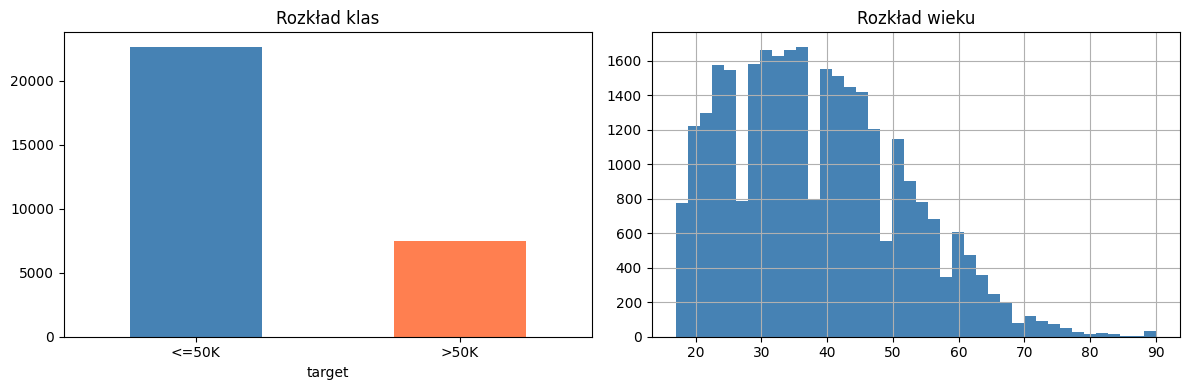

In [10]:
# Encoding targetu: '>50K' → 1, '<=50K' → 0
df_clean['target'] = (df_clean[target_col] == '>50K').astype(int)

print(f"Balans klas po encodingu:")
print(df_clean['target'].value_counts(normalize=True).round(3))

# Wizualizacja
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_clean['target'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'coral'])
ax[0].set_title('Rozkład klas')
ax[0].set_xticklabels(['<=50K', '>50K'], rotation=0)

df_clean['age'].hist(bins=40, ax=ax[1], color='steelblue')
ax[1].set_title('Rozkład wieku')
plt.tight_layout()
plt.show()

## 4. Wybór featurów

Wybieramy tylko te featury, które LLM będzie w stanie wyciągnąć z opisu użytkownika w aplikacji Streamlit. Pomijamy:
- `fnlwgt` (techniczna waga próbki)
- `education_num` (redundantne z `education`)
- `capital_gain`, `capital_loss` (użytkownik zwykle tego nie wie)
- `race`, `native_country` (etycznie wrażliwe — nie pytamy)
- `relationship` (silnie skorelowane z `marital_status`)

In [11]:
# Featury które LLM wyciąga z opisu użytkownika
NUMERIC_FEATURES = ['age', 'hours_per_week']
CATEGORICAL_FEATURES = ['sex', 'education', 'occupation', 'marital_status', 'workclass']

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Sanity check — czy wszystkie kolumny istnieją
missing = [f for f in ALL_FEATURES if f not in df_clean.columns]
if missing:
    print(f"⚠️  Brakujące kolumny: {missing}")
    print(f"Dostępne kolumny: {df_clean.columns.tolist()}")
else:
    print(f"✅ Wszystkie {len(ALL_FEATURES)} featurów dostępne")

X = df_clean[ALL_FEATURES].copy()
y = df_clean['target'].copy()
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

✅ Wszystkie 7 featurów dostępne

X shape: (30162, 7), y shape: (30162,)


## 5. Feature selection — mutual information

Mutual information mierzy jak bardzo każdy feature redukuje niepewność co do targetu. Obsługuje zarówno cechy numeryczne, jak i kategoryczne (po zakodowaniu).

       feature  mi_score
marital_status  0.109150
           age  0.067790
     education  0.064736
    occupation  0.064597
hours_per_week  0.041238
           sex  0.025928
     workclass  0.011856


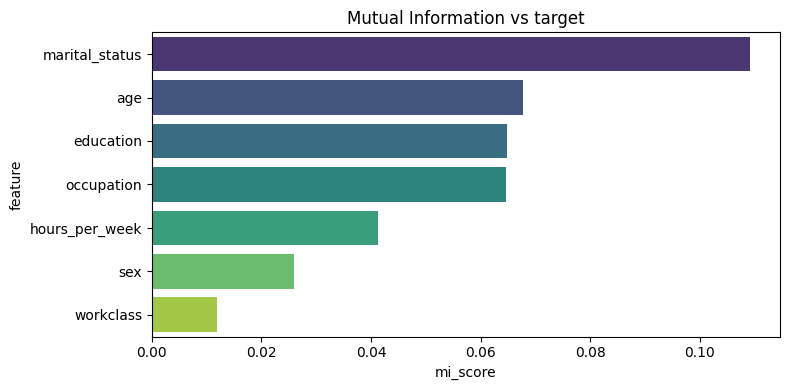

In [12]:
# Tymczasowe label encoding tylko do liczenia MI
X_for_mi = X.copy()
for col in CATEGORICAL_FEATURES:
    X_for_mi[col] = X_for_mi[col].astype('category').cat.codes

mi_scores = mutual_info_classif(
    X_for_mi, y,
    discrete_features=[X_for_mi.columns.get_loc(c) for c in CATEGORICAL_FEATURES],
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print(mi_df.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=mi_df, y='feature', x='mi_score', palette='viridis')
plt.title('Mutual Information vs target')
plt.tight_layout()
plt.show()

**Wnioski:** wszystkie wybrane featury mają niezerowy mutual information, więc zostawiamy komplet. W razie potrzeby można odciąć featury z MI < 0.01.

## 6. Pipeline preprocessingu

Używamy `ColumnTransformer` żeby:
- numeryczne → `StandardScaler`  
- kategoryczne → `OneHotEncoder(handle_unknown='ignore')` — żeby model przeżył nieznane wartości w produkcji

Wszystko w jednym `Pipeline`, który zapiszemy razem z modelem. Dzięki temu w Streamlicie wystarczy `pipeline.predict_proba(df_input)` — nie musimy ręcznie kodować featurów.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ]
)

# Test żeby zobaczyć ile będzie kolumn po encodingu
preprocessor.fit(X)
n_features_out = preprocessor.transform(X.head(1)).shape[1]
print(f"Liczba featurów po encodingu: {n_features_out}")

Liczba featurów po encodingu: 48


## 7. Train / test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,           # zachowuje proporcje klas
    random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Balans klas (train): {y_train.mean():.3f}")
print(f"Balans klas (test):  {y_test.mean():.3f}")

Train: (24129, 7), Test: (6033, 7)
Balans klas (train): 0.249
Balans klas (test):  0.249


## 8. Baseline — Logistic Regression

In [21]:
baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (baseline) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1:       {f1_score(y_test, y_pred_base):.4f}")
print(f"AUC:      {roc_auc_score(y_test, y_proba_base):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=['<=50K', '>50K']))

=== Logistic Regression (baseline) ===
Accuracy: 0.8001
F1:       0.6753
AUC:      0.8919

              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      4531
        >50K       0.57      0.83      0.68      1502

    accuracy                           0.80      6033
   macro avg       0.75      0.81      0.77      6033
weighted avg       0.84      0.80      0.81      6033



## 9. Model główny — LightGBM

LightGBM dobrze radzi sobie z mieszanymi typami danych, jest szybki i osiąga zwykle ~87% accuracy / ~0.93 AUC na tym datasecie.

In [22]:
lgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight='balanced',   # ważne przy niezbalansowanych klasach
        random_state=RANDOM_STATE,
        verbose=-1,
    ))
])

lgb_model.fit(X_train, y_train)
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1:       {f1_score(y_test, y_pred):.4f}")
print(f"AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

=== LightGBM ===
Accuracy: 0.8054
F1:       0.6851
AUC:      0.8994

              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      4531
        >50K       0.57      0.85      0.69      1502

    accuracy                           0.81      6033
   macro avg       0.76      0.82      0.77      6033
weighted avg       0.85      0.81      0.82      6033



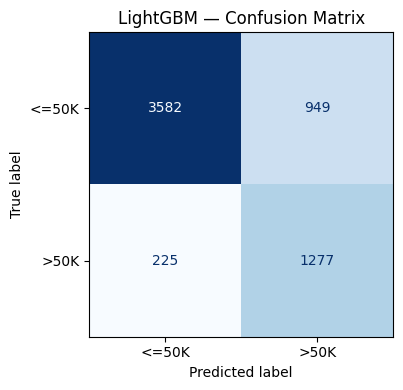

In [23]:
# Macierz pomyłek
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LightGBM — Confusion Matrix')
plt.tight_layout()
plt.show()

## 10. Cross-validation (5-fold stratified)

**Po co to robimy?** Pojedynczy split train/test (sekcja 7) może mieć farta — może akurat trafiły się "łatwe" przykłady do testu i wynik jest zawyżony. Cross-validation eliminuje ten problem.

**Jak działa 5-fold stratified:**
1. Dzielimy cały zbiór na 5 równych części (foldów).
2. Trenujemy 5 razy: za każdym razem 4 foldy idą na trening, 1 na test.
3. Każdy fold raz pełni rolę testu — czyli każdy rząd danych jest przetestowany.
4. **Stratified** = każdy fold ma taki sam udział klasy `>50K` (~24%) jak cały zbiór. Bez tego mogłoby się zdarzyć, że któryś fold ma 10% bogatych, inny 35% i wyniki by skakały.

**Co czytamy z wyniku:**
- `AUC: 0.8904 ± 0.0041` — średni wynik po 5 foldach ± odchylenie standardowe.
- Małe odchylenie (0.004) = model jest **stabilny**, daje podobne wyniki niezależnie od splitu. Gdyby było np. ±0.05, znaczyłoby że model jest kapryśny i wynik z sekcji 9 mógłby być przypadkiem.


In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(lgb_model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(lgb_model, X, y, cv=skf, scoring='f1',      n_jobs=-1)

print(f"AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"F1:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

AUC: 0.8904 ± 0.0041
F1:  0.6719 ± 0.0074


## 11. Feature importance (LightGBM)

**Co to mierzy?** Jak często model używa danego featuru przy podejmowaniu decyzji (liczba splitów drzewa na tej cesze). Im wyższy słupek, tym mocniej dany feature wpływa na predykcję.

**Po co to oglądać?**
- **Sanity check** — czy model "rozumuje" sensownie? Jeśli na górze są dziwne featury, coś może być nie tak (np. data leak).
- **Selekcja** — featury z importance ≈ 0 można rozważyć do wyrzucenia (mniejszy model, szybszy inference).
- **Storytelling** — łatwiej wytłumaczyć biznesowi/sobie samemu dlaczego model przewiduje tak a nie inaczej.

**Uwaga:** po `OneHotEncoder` każda wartość kategoryczna jest osobną kolumną (np. `Stan cywilny: Żonaty / Zamężna`), więc w rankingu pojawiają się konkretne wartości, nie całe kolumny.


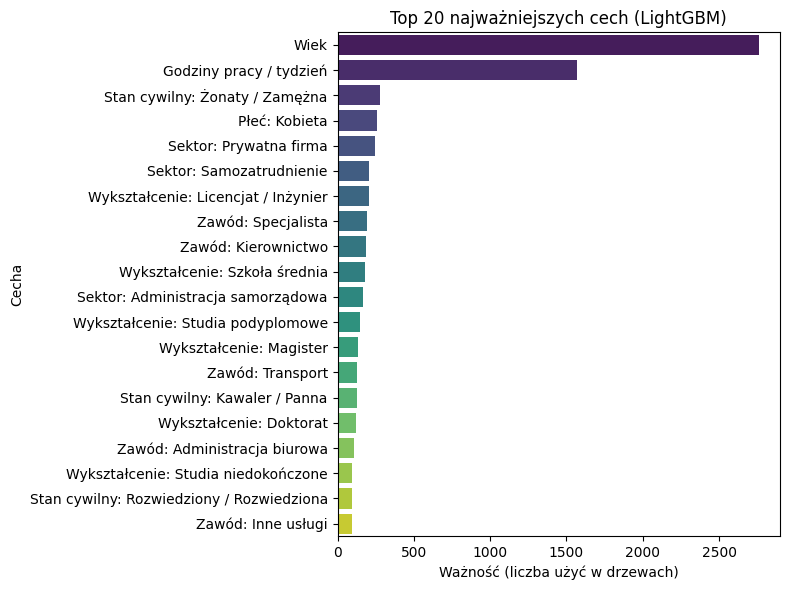

In [25]:
# Wyciągnięcie nazw kolumn po preprocessingu
ohe = lgb_model.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = NUMERIC_FEATURES + list(ohe_features)

# Tłumaczenie technicznych nazw na ludzki polski
# (numeryczne + prefiksy kolumn po OneHotEncoder, np. 'sex_Kobieta' → 'Płeć: Kobieta')
FEATURE_LABELS_PL = {
    'age': 'Wiek',
    'hours_per_week': 'Godziny pracy / tydzień',
}
PREFIX_LABELS_PL = {
    'sex_': 'Płeć: ',
    'education_': 'Wykształcenie: ',
    'occupation_': 'Zawód: ',
    'marital_status_': 'Stan cywilny: ',
    'workclass_': 'Sektor: ',
}

def prettify(name: str) -> str:
    if name in FEATURE_LABELS_PL:
        return FEATURE_LABELS_PL[name]
    for prefix, pl in PREFIX_LABELS_PL.items():
        if name.startswith(prefix):
            return pl + name[len(prefix):]
    return name

importances = lgb_model.named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
imp_df['feature'] = imp_df['feature'].apply(prettify)
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, y='feature', x='importance', palette='viridis')
plt.title('Top 20 najważniejszych cech (LightGBM)')
plt.xlabel('Ważność (liczba użyć w drzewach)')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()


## 12. Zapis modelu lokalnie

Zapisujemy:
- pełny `Pipeline` (preprocessor + classifier) → `model_v{timestamp}.pkl`
- metadane (oczekiwane kolumny, dozwolone wartości kategoryczne, metryki) → `metadata_v{timestamp}.json`

Metadane są kluczowe dla aplikacji Streamlit — LLM zwraca JSON, ale musimy zwalidować, czy wartości są zgodne z tym, co model widział w treningu.

In [26]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f"model_v{timestamp}.pkl"
metadata_filename = f"metadata_v{timestamp}.json"

model_path = os.path.join(MODELS_DIR, model_filename)
metadata_path = os.path.join(MODELS_DIR, metadata_filename)

# Zapis modelu
joblib.dump(lgb_model, model_path)
print(f"✅ Model zapisany: {model_path}")

# Zapis metadanych
metadata = {
    'version': timestamp,
    'created_at': datetime.now().isoformat(),
    'model_type': 'LightGBM',
    'features': {
        'numeric': NUMERIC_FEATURES,
        'categorical': CATEGORICAL_FEATURES,
    },
    'categorical_values': {
        col: sorted(df_clean[col].dropna().unique().tolist())
        for col in CATEGORICAL_FEATURES
    },
    'numeric_ranges': {
        col: {'min': float(df_clean[col].min()), 'max': float(df_clean[col].max())}
        for col in NUMERIC_FEATURES
    },
    'target': {
        'name': 'income_above_50k',
        'classes': {'0': '<=50K', '1': '>50K'},
    },
    'metrics': {
        'test_accuracy': float(accuracy_score(y_test, y_pred)),
        'test_f1': float(f1_score(y_test, y_pred)),
        'test_auc': float(roc_auc_score(y_test, y_proba)),
        'cv_auc_mean': float(cv_auc.mean()),
        'cv_auc_std': float(cv_auc.std()),
    },
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"✅ Metadane zapisane: {metadata_path}")
print(f"\nDozwolone wartości dla 'education': {metadata['categorical_values']['education']}")

✅ Model zapisany: models\model_v20260427_130845.pkl
✅ Metadane zapisane: models\metadata_v20260427_130845.json

Dozwolone wartości dla 'education': ['Doktorat', 'Gimnazjum (9 klasa)', 'Licencjat / Inżynier', 'Liceum (10 klasa)', 'Liceum (11 klasa)', 'Liceum (12 klasa)', 'Magister', 'Przedszkole', 'Studia niedokończone', 'Studia podyplomowe', 'Studium akademickie', 'Studium zawodowe', 'Szkoła podstawowa (1-4 klasa)', 'Szkoła podstawowa (5-6 klasa)', 'Szkoła podstawowa (7-8 klasa)', 'Szkoła średnia']


## 13. Upload do MinIO / DO Spaces (S3-compatible)

Sekcja uruchamiana po skonfigurowaniu MinIO na Hetznerze. Kod jest identyczny dla DO Spaces — zmienia się tylko `endpoint_url`.

**Wymagane zmienne środowiskowe:**
- `S3_ENDPOINT_URL` (np. `https://minio.twojadomena.pl`)
- `S3_ACCESS_KEY`
- `S3_SECRET_KEY`
- `S3_BUCKET` (np. `adult-income-models`)

In [27]:
# import boto3
# from botocore.client import Config

# s3_client = boto3.client(
#     's3',
#     endpoint_url=os.environ['S3_ENDPOINT_URL'],
#     aws_access_key_id=os.environ['S3_ACCESS_KEY'],
#     aws_secret_access_key=os.environ['S3_SECRET_KEY'],
#     config=Config(signature_version='s3v4'),
#     region_name='us-east-1',  # MinIO ignoruje, ale boto3 wymaga
# )

# bucket = os.environ['S3_BUCKET']

# s3_client.upload_file(model_path,    bucket, f"models/{model_filename}")
# s3_client.upload_file(metadata_path, bucket, f"models/{metadata_filename}")

# # Tag 'latest' — alias do najnowszej wersji
# s3_client.upload_file(model_path,    bucket, "models/model_latest.pkl")
# s3_client.upload_file(metadata_path, bucket, "models/metadata_latest.json")

# print(f"✅ Wgrano do bucketu '{bucket}'")
print("⏸️  Sekcja zakomentowana — odpalimy po setupie MinIO")

⏸️  Sekcja zakomentowana — odpalimy po setupie MinIO


## 14. Funkcja predykcji (do użycia w Streamlit)

Test end-to-end: symulujemy JSON, który zwróci LLM, i sprawdzamy że pipeline daje sensowną predykcję.

In [28]:
def predict_income(input_dict: dict, model=lgb_model, metadata=metadata) -> dict:
    """
    Predykcja dochodu na podstawie słownika cech.

    Args:
        input_dict: słownik z cechami (z LLM extraction)
        model: wytrenowany Pipeline
        metadata: dict z dozwolonymi wartościami

    Returns:
        dict z predykcją, prawdopodobieństwem i listą braków
    """
    required = NUMERIC_FEATURES + CATEGORICAL_FEATURES
    missing = [f for f in required if f not in input_dict or input_dict[f] in (None, '', 'null')]

    if missing:
        return {
            'success': False,
            'missing_features': missing,
            'message': f"Brakuje danych: {', '.join(missing)}",
        }

    # Zbudowanie DataFrame (jeden wiersz)
    X_input = pd.DataFrame([{f: input_dict[f] for f in required}])

    # Predykcja
    proba = model.predict_proba(X_input)[0, 1]
    pred = int(proba >= 0.5)

    return {
        'success': True,
        'prediction': pred,
        'prediction_label': '>50K' if pred == 1 else '<=50K',
        'probability_above_50k': float(proba),
        'input_used': X_input.iloc[0].to_dict(),
    }


# Test 1: kompletne dane
test_input_1 = {
    'age': 38,
    'sex': 'Female',
    'education': 'Masters',
    'occupation': 'Exec-managerial',
    'hours_per_week': 45,
    'marital_status': 'Married-civ-spouse',
    'workclass': 'Private',
}
print("Test 1 (kompletne dane):")
print(json.dumps(predict_income(test_input_1), indent=2, ensure_ascii=False))

# Test 2: braki
test_input_2 = {
    'age': 25,
    'sex': 'Male',
    'education': 'Bachelors',
    # brakuje occupation, hours_per_week, marital_status, workclass
}
print("\nTest 2 (braki):")
print(json.dumps(predict_income(test_input_2), indent=2, ensure_ascii=False))

Test 1 (kompletne dane):
{
  "success": true,
  "prediction": 0,
  "prediction_label": "<=50K",
  "probability_above_50k": 0.41101560509280977,
  "input_used": {
    "age": 38,
    "hours_per_week": 45,
    "sex": "Female",
    "education": "Masters",
    "occupation": "Exec-managerial",
    "marital_status": "Married-civ-spouse",
    "workclass": "Private"
  }
}

Test 2 (braki):
{
  "success": false,
  "missing_features": [
    "hours_per_week",
    "occupation",
    "marital_status",
    "workclass"
  ],
  "message": "Brakuje danych: hours_per_week, occupation, marital_status, workclass"
}


## ✅ Podsumowanie

Pipeline gotowy:
- ✅ Dane wczytane lokalnie z `adult.csv`
- ✅ Wyczyszczone (braki, whitespace, encoding targetu)
- ✅ Feature selection przez mutual information
- ✅ Wytrenowany LightGBM z cross-validation
- ✅ Model + metadane zapisane lokalnie z wersjonowaniem
- ⏸️ Upload do MinIO/Spaces — gotowy kod, czeka na konfigurację
- ✅ Funkcja `predict_income()` testowo działa z słownikiem (jak w Streamlicie)

**Następne kroki:**
1. Setup MinIO na Hetznerze + odpalenie sekcji 13
2. Aplikacja Streamlit z polem tekstowym
3. LLM extraction (OpenAI structured output)
4. Langfuse — observability dla wywołań LLM
5. Deploy na Hetznerze (Docker + Caddy/Traefik)
